# Apprentissage en LTN

Ce tutoriel explique le concept d'apprentissage en Logic Tensor Networks.

Jusqu'ici, on a vu comment construire des objets LTN (constantes, prédicats, formules) et comment les évaluer, mais jamais comment faire en sorte qu'un prédicat s'améliore au fil du temps. C'est précisément ce que ce notebook introduit : comment apprendre certains symboles du langage (prédicats, fonctions, constantes) en utilisant la satisfaction d'une base de connaissances comme objectif d'entraînement.

Une base de connaissances est simplement un ensemble de formules logiques qu'on souhaite voir vérifiées simultanément. La satisfaire comme objectif ne signifie pas rendre chaque formule strictement vraie, comme ce serait le cas en logique classique, mais trouver les paramètres qui rendent le degré de vérité de chaque formule le plus proche possible de 1. C'est un problème d'optimisation continue, exactement comme minimiser une fonction de perte en apprentissage automatique classique, à la différence que ce qu'on cherche ici à maximiser est un degré de satisfaction logique, et non un score de proximité à une étiquette.

Concrètement, ce qui change pendant l'entraînement, ce sont les poids internes des prédicats et fonctions apprenables (les réseaux de neurones qu'on a construits jusqu'ici), et éventuellement les valeurs de constantes entraînables. La structure logique des formules, elle, reste toujours fixe.

Ce tutoriel suppose une familiarité de base avec les deux premiers notebooks sur LTN (grounding des symboles, puis des connecteurs et quantificateurs).

In [1]:
import torch
import numpy as np
import ltn
import matplotlib.pyplot as plt

## Classification par proximité

On illustre l'apprentissage en LTN avec l'exemple suivant.

Le domaine est le carré $[0,4]\times[0,4]$ : on travaille avec des points en 2D, dont les deux coordonnées sont comprises entre 0 et 4. On dispose de 19 points dans ce domaine, et on cherche à deviner leur classe. Seuls deux d'entre eux sont déjà étiquetés : un point de classe $A$, un autre de classe $B$. Les 17 points restants n'ont aucune étiquette.

Avec seulement deux exemples étiquetés, un classifieur entraîné de façon purement supervisée n'aurait aucune chance d'apprendre quoi que ce soit d'utile. L'idée de cet exemple est de compenser ce manque de données par des connaissances a priori sur le problème, exprimées sous forme de deux hypothèses :
* les classes $A$ et $B$ sont mutuellement exclusives, un point ne peut pas appartenir aux deux à la fois ;
* deux points proches devraient partager la même étiquette.

C'est cette seconde hypothèse qui va faire l'essentiel du travail. Elle rappelle le principe des *k plus proches voisins* : si un point inconnu est proche du point $a$, il est raisonnable de penser qu'il appartient probablement à la même classe que $a$. Elle sera traduite dans la section suivante par une règle logique explicite, qui permettra au modèle d'apprendre à classifier tous les points, en s'appuyant uniquement sur les deux exemples étiquetés et sur cette contrainte de proximité, sans jamais recevoir la vraie étiquette des 17 autres points.

On affiche ci-dessous notre jeu de données de 19 points, en distinguant visuellement les exemples déjà classés des exemples encore inconnus.

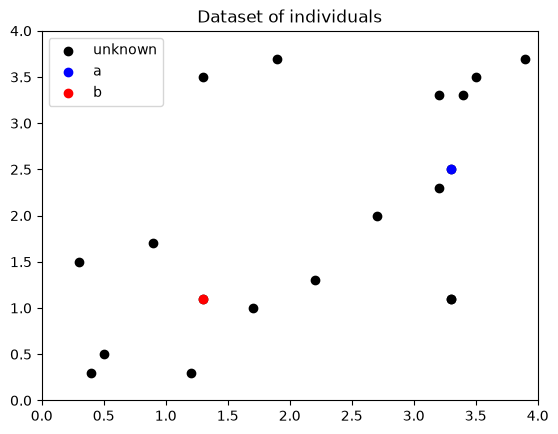

In [2]:
points = np.array(
        [[0.4,0.3], [1.2,0.3], [2.2,1.3], [1.7,1.0], [0.5,0.5], [0.3, 1.5], [1.3, 1.1], [0.9, 1.7],
        [3.4,3.3], [3.2,3.3], [3.2,2.3], [2.7,2.0], [3.5,3.5], [3.3, 2.5], [3.3, 1.1], [1.9, 3.7], [1.3, 3.5],
        [3.3, 1.1],[3.9, 3.7]])
point_a = [3.3, 2.5]
point_b = [1.3, 1.1]
fig, ax = plt.subplots()
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.scatter(points[:,0], points[:,1], color="black", label="unknown")
ax.scatter(point_a[0], point_a[1], color="blue", label="a")
ax.scatter(point_b[0], point_b[1], color="red", label="b")
ax.set_title("Dataset of individuals")
plt.legend();

## Définition de la base de connaissances

On commence par définir un prédicat d'appartenance $C(x,l)$, où $x$ est un individu (un point) et $l$ un label encodé en one-hot désignant l'une des deux classes ($[1,0]$ pour la classe $A$, $[0,1]$ pour la classe $B$). $C(x,l)$ répond donc à la question : "à quel degré le point $x$ appartient-il à la classe désignée par $l$ ?"

$C$ est approximé par un simple perceptron multicouche (MLP). Sa dernière couche, qui calcule une probabilité par classe, utilise une activation `softmax` plutôt qu'une sigmoïde. C'est un choix qui traduit directement la première hypothèse posée plus haut : contrairement à une sigmoïde, qui évaluerait indépendamment la probabilité de chaque classe, le softmax répartit une masse totale de probabilité égale à 1 entre les classes, garantissant ainsi qu'elles restent mutuellement exclusives.

On définit la base de connaissances $\mathcal{K}$ avec les règles suivantes :

$$C(a,l_a)$$
$$C(b,l_b)$$
$$\forall x_1,x_2,l\ \big(\mathrm{Sim}(x_1,x_2) \implies \big(C(x_1,l)\leftrightarrow C(x_2,l)\big)\big)$$

où :
* $a$ et $b$ sont les deux individus déjà classés ;
* $x_1$ et $x_2$ sont des variables parcourant l'ensemble des points ;
* $l_a$ et $l_b$ sont les labels one-hot de $A$ et $B$ ;
* $l$ est une variable parcourant les deux labels possibles ;
* $\mathrm{Sim}$ est un prédicat mesurant la similarité entre deux points, défini par $\mathcal{G}(\mathrm{Sim}):\vec u,\vec v\mapsto\exp(-\|\vec u-\vec v\|)$, la même construction en cloche déjà rencontrée dans les notebooks précédents.

Les deux premières règles sont directes : elles imposent que $a$ soit bien reconnu comme appartenant à la classe $A$, et $b$ à la classe $B$. La troisième règle traduit la seconde hypothèse du problème, celle sur la proximité : pour toute paire de points $x_1,x_2$ et pour n'importe quel label $l$, si $x_1$ et $x_2$ sont similaires, alors ils doivent recevoir le même verdict vis-à-vis de ce label, ce qu'exprime l'équivalence $\leftrightarrow$ à l'intérieur de l'implication.

L'objectif est d'apprendre le prédicat $C$ de façon à maximiser la satisfaction globale de $\mathcal{K}$. En notant $\theta$ l'ensemble des paramètres entraînables, autrement dit les poids du réseau qui implémente $C$, la tâche revient à résoudre :

$$\theta^\ast = \underset{\theta\in\Theta}{\mathrm{argmax}}\ \mathrm{SatAgg}_{\phi\in\mathcal{K}}\ \mathcal{G}_\theta(\phi)$$

où $\mathrm{SatAgg}$ est un opérateur qui agrège les degrés de vérité de toutes les formules de $\mathcal{K}$ en une seule valeur globale, un mécanisme qu'on détaillera dans quelques cellules.

Pour définir cette base de connaissances en LTN, il faut d'abord définir nos prédicats, variables et constantes. Les noms utilisés dans le code ci-dessous reprennent exactement ceux de la formulation mathématique donnée ici.

In [3]:
# Predicate C
class ModelC(torch.nn.Module):
    def __init__(self):
        super(ModelC, self).__init__()
        self.elu = torch.nn.ELU()
        self.softmax = torch.nn.Softmax(dim=1)
        self.dense1 = torch.nn.Linear(2, 5)
        self.dense2 = torch.nn.Linear(5, 5)
        self.dense3 = torch.nn.Linear(5, 2)

    def forward(self, x, l):
        """x: point, l: one-hot label"""
        x = self.elu(self.dense1(x))
        x = self.elu(self.dense2(x))
        prob = self.softmax(self.dense3(x))
        return torch.sum(prob * l, dim=1)

C = ltn.Predicate(ModelC())

# Predicate Sim
Sim = ltn.Predicate(func=lambda u, v: torch.exp(-1. * torch.sqrt(torch.sum(torch.square(u - v), dim=1))))

On définit à présent les variables et constantes correspondant à la formulation du problème : $x_1$ et $x_2$ parcourent l'ensemble des 19 points du dataset, $a$ et $b$ sont les deux points déjà étiquetés, $l_a$ et $l_b$ leurs labels one-hot respectifs, et $l$ est une variable parcourant les deux labels possibles.

In [4]:
# variables and constants
x1 = ltn.Variable("x1", torch.tensor(points))
x2 = ltn.Variable("x2", torch.tensor(points))
a = ltn.Constant(torch.tensor([3.3, 2.5]))
b = ltn.Constant(torch.tensor([1.3, 1.1]))
l_a = ltn.Constant(torch.tensor([1, 0]))
l_b = ltn.Constant(torch.tensor([0, 1]))
l = ltn.Variable("l", torch.tensor([[1, 0], [0, 1]]))

Visualisons la similarité entre chaque point du dataset et le point $a$, telle que la calcule le prédicat $\mathrm{Sim}$. Plus la ligne reliant deux points est épaisse et opaque, plus leur similarité est élevée ; à l'inverse, une ligne fine et presque transparente indique deux points jugés peu similaires.

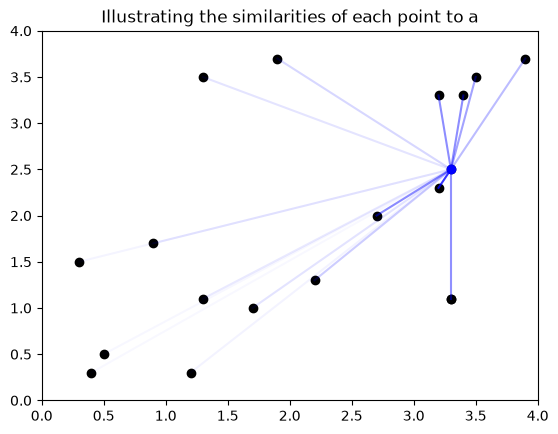

In [5]:
similarities_to_a = Sim(x1, a).value
fig, ax = plt.subplots()
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.scatter(points[:,0], points[:,1], color="black")
ax.scatter(a.value[0], a.value[1], color="blue")
ax.set_title("Illustrating the similarities of each point to a")
for i, sim_to_a in enumerate(similarities_to_a):
    plt.plot([points[i,0], a.value[0]], [points[i,1],a.value[1]], alpha=float(sim_to_a.numpy()), color="blue")

Pour les connecteurs, on utilise la version stable de la configuration produit, présentée dans le notebook complémentaire (`2b-operators-and-gradients.ipynb`).

Un nouvel opérateur apparaît ici : l'équivalence $p\leftrightarrow q$. En LTN, elle n'est pas implémentée comme un opérateur indépendant, mais construite à partir de deux opérateurs déjà connus, selon l'équivalence classique $p\leftrightarrow q \equiv (p\implies q)\land(q\implies p)$. Cet opérateur composite est disponible via `ltn.fuzzy_ops.Equiv`, qui prend en entrée la t-norme et l'implication à utiliser pour sa construction interne.

In [6]:
Not = ltn.Connective(ltn.fuzzy_ops.NotStandard())
And = ltn.Connective(ltn.fuzzy_ops.AndProd())
Or = ltn.Connective(ltn.fuzzy_ops.OrProbSum())
Implies = ltn.Connective(ltn.fuzzy_ops.ImpliesReichenbach())
Equiv = ltn.Connective(ltn.fuzzy_ops.Equiv(ltn.fuzzy_ops.AndProd(), ltn.fuzzy_ops.ImpliesReichenbach()))
Forall = ltn.Quantifier(ltn.fuzzy_ops.AggregPMeanError(p=2), quantifier="f")
Exists = ltn.Quantifier(ltn.fuzzy_ops.AggregPMean(p=6), quantifier="e")

Prédicats, variables et constantes étant maintenant définis, on peut construire la base de connaissances proprement dite.

Quand $\mathcal{K}$ contient plusieurs formules closes, leurs degrés de vérité doivent être agrégés en une seule valeur : c'est le rôle de l'opérateur $\mathrm{SatAgg}$. Une **formule close**, au sens logique du terme, est une formule qui ne contient plus aucune variable libre : toutes ses variables ont été capturées par un quantificateur. C'est une condition nécessaire pour `SatAgg` : si une formule contenait encore une variable libre, son degré de vérité ne serait pas un nombre unique mais tout un ensemble de valeurs, une par valeur possible de cette variable, et `SatAgg` ne saurait pas laquelle utiliser pour représenter la satisfaction de cette formule dans l'agrégation globale.

Quelques exemples permettent de fixer ce critère :

* $\text{EstAmiDe}(x,y)$, sans aucun quantificateur, a deux variables libres. Elle n'est pas close, et son évaluation donne une matrice de résultats plutôt qu'un unique degré de vérité.
* $\forall x\, \text{EstAmiDe}(x,y)$ n'est pas close non plus : seul $x$ est capturé par le quantificateur, $y$ reste libre, et le résultat est encore un vecteur de valeurs, une par $y$ possible.
* $\forall x\,\forall y\, \text{EstAmiDe}(x,y)$ est bien close, puisque les deux variables sont désormais capturées, et son évaluation donne un unique scalaire.
* $\exists y\,\forall x\, \text{EstAmiDe}(x,y)$ est également close, car $x$ et $y$ sont tous deux capturés, peu importe lequel l'est par $\forall$ et lequel par $\exists$ : seul compte le fait que toute variable soit quantifiée, pas l'ordre ni le type des quantificateurs.

Dans notre base de connaissances, $C(a,l_a)$ et $C(b,l_b)$ sont déjà closes puisqu'elles ne contiennent que des constantes, aucune variable : une formule sans variable est automatiquement close, il n'y a simplement rien à quantifier. La troisième formule, en revanche, ne devient close que grâce au $\forall x_1,x_2,l$ placé devant, qui capture les trois variables présentes.

En LTN, $\mathrm{SatAgg}$ est disponible via `ltn.fuzzy_ops.SatAgg`. Le constructeur `SatAgg()` prend en entrée un opérateur d'agrégation, utilisé ensuite pour combiner les valeurs de vérité fournies lors de l'appel. Nous recommandons d'utiliser ici encore `pMeanError`, le même opérateur déjà utilisé pour implémenter $\forall$, ce qui est d'ailleurs le choix par défaut de `SatAgg()`. Le paramètre $p$ y joue exactement le même rôle que pour les quantificateurs : plus $p$ est faible, plus l'agrégation se rapproche d'une simple moyenne entre les formules ; plus $p$ est élevé, plus elle se rapproche du pire cas parmi les formules de $\mathcal{K}$.

`SatAgg` accepte directement des instances de `LTNObject` en entrée, il n'est donc pas nécessaire d'accéder à l'attribut `value` des formules avant de les lui passer.

Puisqu'on cherche à **maximiser** le niveau de satisfaction global de $\mathcal{K}$, et que les algorithmes d'optimisation de PyTorch sont conçus pour **minimiser** une fonction de perte, on définit la perte comme $1-\mathrm{SatAgg}$ : minimiser cette quantité revient exactement à maximiser la satisfaction.

Dans la boucle d'entraînement ci-dessous, chaque itération calcule d'abord les degrés de vérité des trois formules de $\mathcal{K}$ (phase *forward*), puis ajuste les poids du prédicat $C$ par rétropropagation pour réduire la perte (phase *backward*), par descente de gradient, appliquée ici à un vrai objectif d'entraînement.

---
### Exemple

Opérateurs (config imposée) :
- Négation : $\neg u = 1-u$
- T-norme (And, produit) : $u\land v = uv$
- T-conorme (Or, produit) : $u\lor v = u+v-uv$
- Implication de Reichenbach : $u\to v = 1-u+uv$
- Équivalence : $\text{Equiv}(u,v) = (1-u+uv)(1-v+uv)$

Rappelons que dans toutes ces formules, $u$ et $v$ sont des **scalaires**, des valeurs de vérité individuelles dans $[0,1]$. 

Concrètement : $x_1$ et $x_2$ parcourent **indépendamment** le même domaine $\{q_0,q_1,q_2\}$, 
donc toute formule $\phi(x_1,x_2)$ se calcule sur le produit cartésien $\{q_0,q_1,q_2\}\times\{q_0,q_1,q_2\}$, une grille $3\times3$ indexée par $(i,j)$. 

#### Les données

Considérons 3 points (au lieu de 19), pour pouvoir tout calculer à la main. Soit :

$$q_0 = (0,0) \qquad q_1 = (3,3) \qquad q_2 = (0.1,\,0.1)$$

#### Étape 1 : `Sim(x1, x2)`

Grounding sur $(i,j)\in\{0,1,2\}^2$ — matrice $3\times3$ par construction directe :

$$\text{Sim}[i,j] = \begin{pmatrix} 1 & 0.014 & 0.868 \\ 0.014 & 1 & 0.017 \\ 0.868 & 0.017 & 1 \end{pmatrix}$$

Symétrique, diagonale à $1$ (chaque point est identique à lui-même géométriquement).

#### Étape 2 : `C(x, l)` — le prédicat de confiance

$C$ est une fonction d'**un seul point** et d'un label : $C(q_i,l)\in[0,1]$. Ligne = point, colonne = label :

$$C(x,l) = \begin{pmatrix} 0.9 & 0.1 \\ 0.2 & 0.8 \\ 0.5 & 0.5 \end{pmatrix}, \qquad x\in\{q_0,q_1,q_2\}$$

Puisque $x_1$ et $x_2$ parcourent le **même** domaine avec le **même** prédicat $C$, on a $C(x_1,l)=C(x_2,l)$ 
au sens où c'est la même fonction mais évaluée à des indices potentiellement différents ($i$ pour $x_1$, $j$ pour $x_2$).

Pour un label $l$ fixé, on extrait la colonne correspondante comme un **vecteur** indexé par point :
$$c_A = (C(q_0,A), C(q_1,A), C(q_2,A)) = (0.9,\ 0.2,\ 0.5)$$
$$c_B = (C(q_0,B), C(q_1,B), C(q_2,B)) = (0.1,\ 0.8,\ 0.5)$$

Remarquons que : $c_B = 1-c_A$ terme à terme (car $C(q_i,B)=1-C(q_i,A)$, les deux colonnes somment à 1).

#### Étape 3 : `Equiv(C(x1,l), C(x2,l))` 

**Définition indicielle** :
$$M_l[i,j] := \text{Equiv}\big(c_l[i],\,c_l[j]\big), \qquad u=c_l[i],\ v=c_l[j],\qquad (i,j)\in\{0,1,2\}^2$$

$u$ et $v$ sont deux valeurs scalaires **du même vecteur** $c_l$, prises à deux indices distincts.

Pour $l=A$, $c_A=(0.9,0.2,0.5)$ :

| $(i,j)$ | $(u,v)$ | $\text{Implies}(u,v)$ | $\text{Implies}(v,u)$ | $\text{Equiv}=$ produit |
|---|---|---|---|---|
| $(0,0)$ | $(0.9,0.9)$ | $0.91$ | $0.91$ | $0.8281$ |
| $(0,1)$ | $(0.9,0.2)$ | $0.28$ | $0.98$ | $0.2744$ |
| $(0,2)$ | $(0.9,0.5)$ | $0.55$ | $0.95$ | $0.5225$ |
| $(1,1)$ | $(0.2,0.2)$ | $0.84$ | $0.84$ | $0.7056$ |
| $(1,2)$ | $(0.2,0.5)$ | $0.90$ | $0.60$ | $0.54$   |
| $(2,2)$ | $(0.5,0.5)$ | $0.75$ | $0.75$ | $0.5625$ |

(symétrique car $\text{Equiv}(u,v)=\text{Equiv}(v,u)$ par construction ; produit de deux implications croisées)

$$M_A[i,j] = \begin{pmatrix} 0.8281 & 0.2744 & 0.5225 \\ 0.2744 & 0.7056 & 0.5400 \\ 0.5225 & 0.5400 & 0.5625 \end{pmatrix}$$

**Pourquoi $M_B = M_A$ ?**

- Comme $c_B = 1-c_A$ terme à terme, $M_B[i,j] = \text{Equiv}(1-c_A[i],\,1-c_A[j])$.

- Vérifions l'identité $\text{Equiv}(1-u,1-v)=\text{Equiv}(u,v)$ :
  
On a :
$$\text{Implies}(1-u,1-v) = 1-(1-u)+(1-u)(1-v) = u+1-u-v+uv = 1-v+uv = \text{Implies}(v,u)$$

Donc $\text{Equiv}(1-u,1-v) = \text{Implies}(1-u,1-v)\times\text{Implies}(1-v,1-u) = \text{Implies}(v,u)\times\text{Implies}(u,v) = \text{Equiv}(u,v)$.

D'où $M_B[i,j]=\text{Equiv}(1-c_A[i],1-c_A[j])=\text{Equiv}(c_A[i],c_A[j])=M_A[i,j]$ — **exactement** les mêmes 9 valeurs, pour une raison algébrique précise et non par coïncidence.

#### Étape 4 : `Implies(Sim(x1,x2), Equiv(C(x1,l), C(x2,l)))`

Même grille d'indices $(i,j)$ — c'est ce qui permet à cette implication d'être calculée case par case : $\text{Sim}[i,j]$ et $M_l[i,j]$ partagent exactement les mêmes indices $(i,j)$ par construction (les deux viennent du grounding de $x_1,x_2$ sur $\{q_0,q_1,q_2\}^2$), donc l'implication elementwise a un sens :

$$N_l[i,j] = \text{Implies}\big(\text{Sim}[i,j],\,M_l[i,j]\big) = 1-\text{Sim}[i,j]+\text{Sim}[i,j]\cdot M_l[i,j]$$

$$N_A = N_B = \begin{pmatrix} 0.8281 & 0.9896 & 0.5855 \\ 0.9896 & 0.7056 & 0.9924 \\ 0.5855 & 0.9924 & 0.5625 \end{pmatrix}$$

#### Et la diagonale ?

LTN n'exclut pas la diagonale $i=j$ : le code d'entraînement `Forall([x1, x2, l], ...)` agrège sur **toutes** les paires, diagonale comprise.

On pourrait croire que comparer un point à lui-même est trivialement vrai, mais ce n'est pas le cas en logique floue : $\text{Equiv}(u,u) = (1-u+u^2)^2$ ne vaut 1 que si $u$ vaut 0 ou 1. Pour $q_2$, dont la confiance est de $0.5$, la case $(2,2)$ ne vaut que $0.5625$ : c'est même la pire case du tableau. Les cases de la diagonale poussent donc le réseau à donner des verdicts **tranchés**, proches de 0 ou de 1, plutôt que des confiances indécises.

#### Étape 5 — `pMeanError` sur toutes les paires

$$\text{pMeanError} = 1-\left(\frac{1}{n}\sum_{l}\sum_{i,j}\big(1-N_l[i,j]\big)^p\right)^{1/p}$$

Avec $p=2$ et $n = 3\times3\times2 = 18$ cases :

| $(i,j)$ | $N_l[i,j]$ | $1-N_l[i,j]$ | $(1-N_l[i,j])^2$ | nombre de cases par label |
|---|---|---|---|---|
| $(0,0)$ | $0.8281$ | $0.1719$ | $0.029550$ | 1 |
| $(1,1)$ | $0.7056$ | $0.2944$ | $0.086671$ | 1 |
| $(2,2)$ | $0.5625$ | $0.4375$ | $0.191406$ | 1 |
| $(0,1),\,(1,0)$ | $0.9896$ | $0.0104$ | $0.000109$ | 2 |
| $(1,2),\,(2,1)$ | $0.9924$ | $0.0076$ | $0.000058$ | 2 |
| $(0,2),\,(2,0)$ | $0.5855$ | $0.4145$ | $0.171834$ | 2 |

Pour un label, la somme vaut $0.307627 + 2\times0.172001 = 0.651629$, et comme $N_A = N_B$, on la compte deux fois :

$$\sum_{l}\sum_{i,j}(1-N_l[i,j])^2 = 2\times0.651629 = 1.303258$$

$$\text{pMeanError} = 1-\left(\frac{1.303258}{18}\right)^{1/2} = 1-(0.072403)^{1/2} = 1-0.26908 = \boxed{0.731}$$

#### Loss

$$\text{loss} = 1-\text{sat\_agg}\big(C(a,l_a),\,C(b,l_b),\,0.731\big)$$
---

### Lecture d'une cellule $T[i,j,l]$

#### Ce que représente formellement une cellule

$$T[i,j,l] = \text{Implies}\big(\text{Sim}(q_i,q_j),\ \text{Equiv}(C(q_i,l),\,C(q_j,l))\big)$$

Une cellule $T[i,j,l]$ répond à une seule question précise, fixée par les trois indices : si l'on prend le point $q_i$ pour $x_1$, le point $q_j$ pour $x_2$, et le label $l$, à quel degré l'axiome *"s'ils sont similaires, alors ils reçoivent la même confiance pour ce label"* est-il vérifié ? Il s'agit d'un unique nombre réel dans $[0,1]$ ; $i$, $j$ et $l$ sont tous les trois fixés simultanément pour cette cellule.

#### Lecture détaillée d'une cellule précise

Prenons $T[0,2,A]$, c'est-à-dire $i=0$, $j=2$, $l=A$ :

1. On instancie $x_1=q_0$, $x_2=q_2$, $l=A$.
2. $\text{Sim}(q_0,q_2)=0.868$ : les deux points sont géométriquement très proches.
3. $\text{Equiv}(C(q_0,A),\,C(q_2,A)) = \text{Equiv}(0.9,\,0.5) = 0.5225$ : le réseau attribue $90\%$ de confiance à $q_0$ pour la classe $A$, mais seulement $50\%$ à $q_2$ ; ce qui marque un désaccord.
4. $\text{Implies}(0.868,\,0.5225) = 0.5855$.

**Interprétation.** Une valeur de $0.5855$, assez loin de $1$, indique une violation de l'axiome : deux points proches ($\text{Sim}$ élevé) devraient logiquement recevoir des confiances proches pour la classe $A$, ce qui n'est pas le cas ici. C'est ce type de cellule qui produira un signal de gradient fort, poussant le réseau à rapprocher $C(q_0,A)$ et $C(q_2,A)$.

---
#### L'approche alternative : ne comparer que chaque point à $a$ et $b$

On pourrait effectivement imaginer une règle plus simple : pour chaque point inconnu $x$, comparer sa similarité à $a$ et à $b$ seulement, et en déduire directement sa classe (un peu comme un vrai algorithme des k-plus-proches-voisins, avec $k=1$ et seulement deux voisins de référence). Ça donnerait quelque chose comme :

$$\forall x\ \big(\mathrm{Sim}(x,a) \implies C(x,l_a)\big) \qquad \forall x\ \big(\mathrm{Sim}(x,b) \implies C(x,l_b)\big)$$

L'approche alternative reviendrait à n'éclairer que les points suffisamment proches des deux seules lampes $a$ et $b$ ; tout point trop éloigné resterait dans le noir, même s'il est entouré d'autres points déjà bien éclairés. La règle du notebook, elle, fait que chaque point éclairé illumine à son tour ses voisins, permettant à la lumière de se propager d'un bout à l'autre du nuage de points, même très loin des deux sources originales, tant qu'il existe un chemin de proximités successives.

**C'est précisément pour ça que le coût de calcul (produit cartésien complet, $19\times19$ paires plutôt que $19\times2$) est justifié** : il ne s'agit pas d'une lourdeur inutile, c'est ce qui permet à l'information de circuler à travers tout le graphe de proximités, et pas seulement depuis les deux points sources.

In [7]:
# by default, SatAgg uses the pMeanError
sat_agg = ltn.fuzzy_ops.SatAgg()

# we need to learn the parameters of the predicate C
optimizer = torch.optim.Adam(C.parameters(), lr=0.001)

for epoch in range(2000):
    optimizer.zero_grad()
    loss = 1. - sat_agg(
        C(a, l_a),
        C(b, l_b),
        Forall([x1, x2, l], Implies(Sim(x1, x2), Equiv(C(x1, l), C(x2, l))))
    )
    loss.backward()
    optimizer.step()
    if epoch%200 == 0:
        print("Epoch %d: Sat Level %.3f "%(epoch, 1 - loss.item()))
print("Training finished at Epoch %d with Sat Level %.3f" %(epoch, 1 - loss.item()))

Epoch 0: Sat Level 0.487 
Epoch 200: Sat Level 0.726 
Epoch 400: Sat Level 0.935 
Epoch 600: Sat Level 0.955 
Epoch 800: Sat Level 0.958 
Epoch 1000: Sat Level 0.959 
Epoch 1200: Sat Level 0.959 
Epoch 1400: Sat Level 0.959 
Epoch 1600: Sat Level 0.959 
Epoch 1800: Sat Level 0.959 
Training finished at Epoch 1999 with Sat Level 0.960


Après quelques centaines d'itérations, le système a appris à identifier les points proches de $a$ (respectivement de $b$) comme appartenant à la classe $A$ (respectivement $B$), en s'appuyant uniquement sur les règles de la base de connaissances, sans jamais avoir reçu d'étiquette explicite pour les 17 points non classés au départ.

On affiche ci-dessous deux graphiques montrant que notre LTN a effectivement appris à classifier les points en utilisant la satisfaction de la base de connaissances comme objectif. La couleur est d'autant plus claire que le prédicat $C$ est satisfait à un degré élevé. À gauche, on observe que $C$ classe correctement les points proches de la classe $A$ ; à droite, ceux proches de la classe $B$.

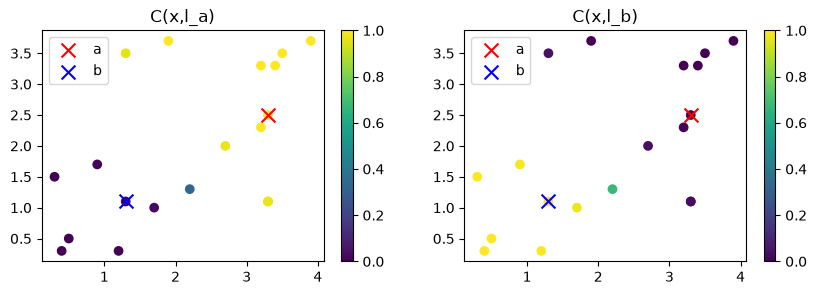

In [11]:
fig = plt.figure(figsize=(10, 3))

fig.add_subplot(1, 2, 1)
plt.scatter(x1.value[:, 0], x1.value[:, 1], c=C(x1, l_a).value.detach().numpy(), vmin=0, vmax=1)
plt.scatter(a.value[0], a.value[1], marker="x", color="red", s=100, label="a")
plt.scatter(b.value[0], b.value[1], marker="x", color="blue", s=100, label="b")
plt.title("C(x,l_a)")
plt.legend()
plt.colorbar()

fig.add_subplot(1, 2, 2)
plt.scatter(x1.value[:, 0], x1.value[:, 1], c=C(x1, l_b).value.detach().numpy(), vmin=0, vmax=1)
plt.scatter(a.value[0], a.value[1], marker="x", color="red", s=100, label="a")
plt.scatter(b.value[0], b.value[1], marker="x", color="blue", s=100, label="b")
plt.title("C(x,l_b)")
plt.legend()
plt.colorbar()

plt.show();

## Cas particuliers

### Variables groundées par batch

Dans la plupart des tâches d'apprentissage, on travaille par batchs de données plutôt qu'avec l'ensemble complet du dataset à chaque itération, pour rendre l'entraînement efficace, notamment lorsque le dataset devient trop volumineux pour être traité en une seule fois.

En LTN, travailler par batchs ne demande aucun mécanisme particulier : il suffit de grounder les variables avec des valeurs différentes à chaque étape d'entraînement. En PyTorch, ces valeurs sont généralement fournies par un `DataLoader`, qui découpe le dataset en sous-ensembles et les distribue au fil des itérations.

Reprenons le même exemple de classification, mais avec un dataset bien plus grand, 10000 points, qui nécessite cette fois d'être subdivisé en mini-batchs.

On affiche ci-dessous ce nouveau dataset, généré aléatoirement. Les points $a$ et $b$ ont été choisis volontairement assez éloignés l'un de l'autre, pour que l'exemple reste lisible.

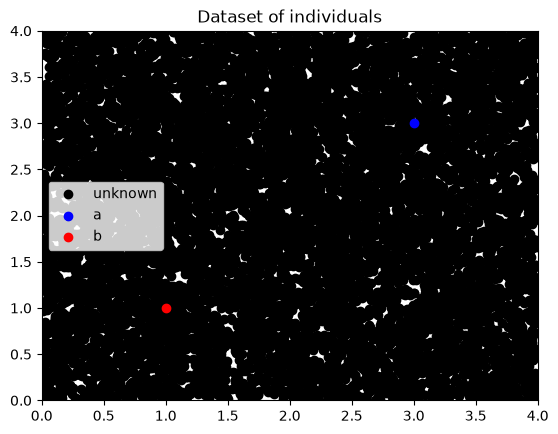

In [12]:
r1 = 0
r2 = 4
points = (r1 - r2) * torch.rand((10000, 2)) + r2
points[-1] = torch.tensor([3., 3.])
points[-2] = torch.tensor([1., 1.])
points_a = torch.tensor([3., 3.])
points_b = torch.tensor([1., 1.])
a = ltn.Constant(torch.tensor([3., 3.]))
b = ltn.Constant(torch.tensor([1., 1.]))

fig, ax = plt.subplots()
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.scatter(points[:,0], points[:,1], color="black", label="unknown")
ax.scatter(points_a[0], points_a[1], color="blue", label="a")
ax.scatter(points_b[0], points_b[1], color="red", label="b")
ax.set_title("Dataset of individuals")
plt.legend();

Définissons maintenant un chargeur de données, qui prend l'intégralité du dataset en entrée et renvoie, à chaque itération, un batch de points. On peut choisir la taille de ce batch, ainsi que si les données doivent être mélangées à chaque epoch.

Comme annoncé, il suffit ensuite d'ajouter quelques lignes de code qui parcourent ces batchs et regroundent les variables $x_1,x_2$ avec les nouveaux points contenus dans chaque batch, à chaque itération.

Le principe reste rigoureusement identique à l'exemple précédent : on recalcule les mêmes trois formules de la base de connaissances, on agrège leur satisfaction avec `SatAgg`, on rétropropage, on met à jour les poids de $C$. La seule différence est que $x_1$ et $x_2$ ne contiennent plus les 19 points fixes de tout à l'heure, mais 512 points différents à chaque itération, tirés du dataset de 10000 points.

In [13]:
# we define C again to re-initialize its weights
C = ltn.Predicate(ModelC())

# data loader which creates the batches
class DataLoader:
    def __init__(self,
                 dataset,
                 batch_size=1,
                 shuffle=True):
        self.data = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return int(np.ceil(self.data.shape[0] / self.batch_size))

    def __iter__(self):
        n = self.data.shape[0]
        idxlist = list(range(n))
        if self.shuffle:
            np.random.shuffle(idxlist)

        for _, start_idx in enumerate(range(0, n, self.batch_size)):
            end_idx = min(start_idx + self.batch_size, n)
            batch_points = self.data[idxlist[start_idx:end_idx]]

            yield batch_points

train_loader = DataLoader(points, 512)

# by default, SatAgg uses the pMeanError
sat_agg = ltn.fuzzy_ops.SatAgg()

# we need to learn the parameters of the predicate C
optimizer = torch.optim.Adam(C.parameters(), lr=0.001)

for epoch in range(100):
    for (batch_idx, (batch_points)) in enumerate(train_loader):
        x1 = ltn.Variable("x1", batch_points)
        x2 = ltn.Variable("x2", batch_points)
        optimizer.zero_grad()
        loss = 1. - sat_agg(
            C(a, l_a),
            C(b, l_b),
            Forall([x1, x2, l], Implies(Sim(x1, x2), Equiv(C(x1, l), C(x2, l))))
        )
        loss.backward()
        optimizer.step()
    if epoch%10 == 0:
        print("Epoch %d: Sat Level %.3f "%(epoch, 1 - loss.item()))

print("Training finished at Epoch %d with Sat Level %.3f" %(epoch, 1 - loss.item()))

Epoch 0: Sat Level 0.670 
Epoch 10: Sat Level 0.890 
Epoch 20: Sat Level 0.943 
Epoch 30: Sat Level 0.947 
Epoch 40: Sat Level 0.948 
Epoch 50: Sat Level 0.953 
Epoch 60: Sat Level 0.946 
Epoch 70: Sat Level 0.948 
Epoch 80: Sat Level 0.952 
Epoch 90: Sat Level 0.951 
Training finished at Epoch 99 with Sat Level 0.951


On observe qu'après seulement 20 epochs, LTN a déjà appris à classifier correctement les points, malgré la taille bien plus importante du dataset et le fait de ne travailler qu'avec des mini-batchs à chaque itération.

Affichons les mêmes graphiques que pour l'exemple précédent, cette fois sur l'ensemble des 10000 points.

Comme le montrent ces figures, LTN a bien appris à classifier correctement les points. On remarque aussi que certains points, situés au milieu du domaine, restent plus difficiles à classer : c'est cohérent avec l'intuition, puisque leur distance à $a$ et à $b$ est comparable, LTN ne dispose alors d'aucune information de proximité claire pour trancher entre les deux classes.

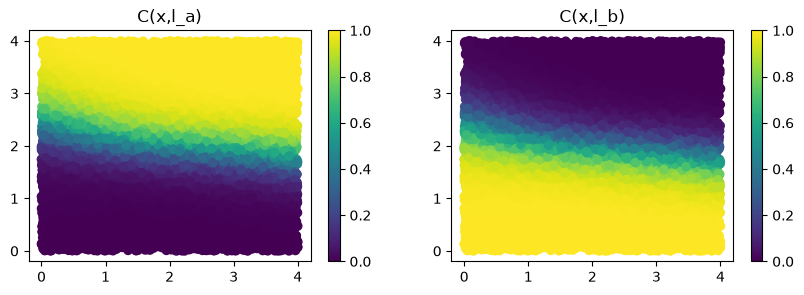

In [14]:
x1 = ltn.Variable("x1", points)
x2 = ltn.Variable("x2", points)
fig = plt.figure(figsize=(10, 3))
fig.add_subplot(1, 2, 1)
plt.scatter(x1.value[:, 0], x1.value[:, 1], c=C(x1, l_a).value.detach().numpy(), vmin=0, vmax=1)
plt.title("C(x,l_a)")
plt.colorbar()
fig.add_subplot(1, 2, 2)
plt.scatter(x1.value[:, 0], x1.value[:, 1], c=C(x1, l_b).value.detach().numpy(), vmin=0, vmax=1)
plt.title("C(x,l_b)")
plt.colorbar()
plt.show();